In [113]:
import re
import os
import ast
import matplotlib
from dataclasses import dataclass, field
from collections import defaultdict
MATCH_PARA = re.compile(r'(\w+)\s+([\d.]+)')
import matplotlib.pyplot as plt
import math
data_path = "quantum_network_compiler/FIG_dataset"
current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))
absolute_path = os.path.join(parent_dir, data_path)
data_path = str(os.path.abspath(absolute_path))
data_path_to_execute = data_path + '/cross_in_rack_ratio'
benchmark = ['xor','qft','grover','rca']
eval = 'test_conn_G_type'
from matplotlib.transforms import Bbox
from Utils import *
import matplotlib.patches as mpatches

In [114]:
data_path = "quantum_network_compiler/FIG_dataset_rebuttal"
current_dir = os.getcwd()
parent_dir = os.path.dirname(os.path.dirname(current_dir))
absolute_path = os.path.join(parent_dir, data_path)
data_path = str(os.path.abspath(absolute_path))
data_path_to_execute = data_path + '/cross_in_rack_ratio'
data_path_list = [data_path+'/cross_in_rack_ratio']
eval = ['test_conn_G_type']
benchmark = ['xor','qft','grover','rca']
big_list = process_files_by_seed(data_path_to_execute)
def grab_data(big_list,eval_key):
    metric_sums = defaultdict(lambda: {'metric_t_sum': 0.0, 'metric_w_sum': 0.0,'epr_sum':0.0, 'count': 0,'in':0,'cross':0,'post':0,'time':0})
    for sublist in big_list:
        for instance in sublist:
            filtered_file_p = {k: v for k, v in instance.file_p.items() if k != 'seed'}
            # if 'baseline'
            file_p_key = frozenset(filtered_file_p.items())
            metric_sums[file_p_key]['metric_t_sum'] += instance.dic_l4['thruput']
            metric_sums[file_p_key]['metric_w_sum'] += instance.dic_l4['avg_wait_time']
            print(instance.dic_l4['avg_wait_time'])
            metric_sums[file_p_key]['epr_sum'] += instance.epr
            metric_sums[file_p_key]['count'] += 1
            metric_sums[file_p_key]['in']  = instance.dic_l2['in_pair']
            metric_sums[file_p_key]['cross']  = instance.dic_l2['cross_pair']
            metric_sums[file_p_key]['post']  = instance.dic_l2['post_in_pair']
            metric_sums[file_p_key]['time']  = instance.dic_l2['time_schedule']
    averages = []
    for file_p_key, values in metric_sums.items():
        avg_metric_t = values['metric_t_sum'] / values['count']
        avg_metric_w = values['metric_w_sum'] / values['count']
        epr = values['epr_sum'] / values['count']
        averages.append({'file_p': dict(file_p_key), 'avg_metric_t': avg_metric_t, 'avg_metric_w': avg_metric_w, 'eproverhead':epr,'in':values['in'],'cross':values['cross'],'post':values['post'],'time':values['time']})
    return averages
averages = grab_data(big_list, eval[0])
result_base = classify_and_sort_averages_1(averages, eval[0], our=1)
diction = [[[], [], [], []], [[], [], [], []], [[], [], [], []],[[],[],[],[]]]
for index, b in enumerate(benchmark):
    for aa in result_base[b]:
        diction[0][index].append(aa['cross'])
        print(aa['cross'])
        diction[1][index].append(aa['in'])
        print(aa['in'])
        diction[2][index].append(aa['avg_metric_t']) 
        print(aa['avg_metric_t'])
        diction[3][index].append(aa['time'])
        print(aa['time'])

0.2
856.1997777777777
97.82892223738062
698.2980392156862
19.75686274509804
22.929411764705883
196.10588235294117
2459.2317924842037
359.16345679012346
35.202139917695476
0.2661728395061728
0.0
4.542307692307692
20.831173571819676
0.0
0.0
9.213483146067416
0.0
0.2
57.19144444444444
43.050980392156866
156.41977777777777
45.44533333333333
18.328223378045443
4.389587362991619
82.26937269372694
0.19953441968739608
77.69185676054543
2.041902228134353
91.41710124078404
1.5906666666666667
0.0
0.0
55.83473251028806
0.0
0.1426671100764882
59.203192550714995
0.2617283950617284
0.19953441968739608
20.77777777777778
0.0
1590.6424691358025
584.7253076155637
0.0
9.980576131687243
71.22347855004989
17.508306503541533
0.0
15.0
240.0
0.11029411764705882
2312.0
15.0
240.0
0.1886094674556213
1352.0
15.0
240.0
1.3783783783783783
185.0
1620.0
4455.0
1.0148680253925826
5986.0
1620.0
4455.0
0.09873874459578065
61526.0
1620.0
4455.0
0.031229758489867677
194526.0
1800.0
7200.0
1.4058106841611997
6402.0
1800.0


[0.058823529411764705, 0.26666666666666666, 0.2, 0.20053209178583306]
[0.9411764705882353, 0.7333333333333333, 0.8, 0.7994679082141669]


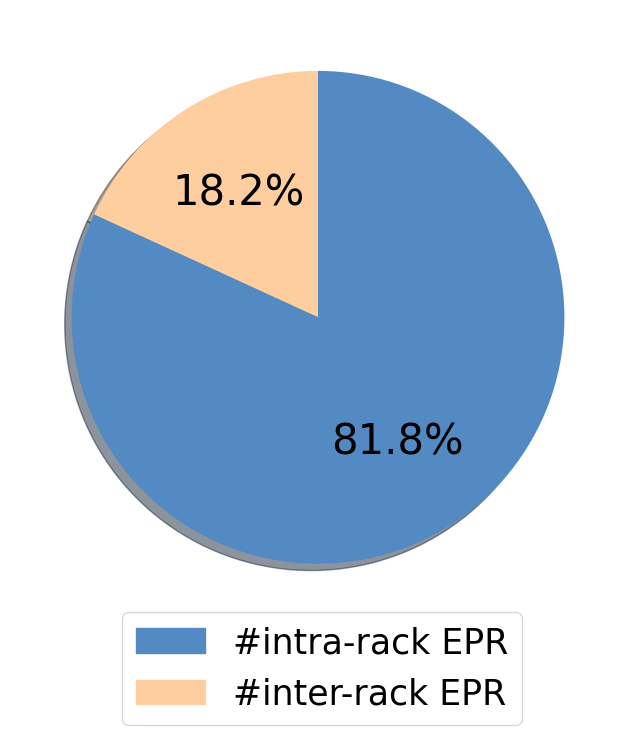

In [115]:
inrack  = []
crossrack = []
for j in [0,1,2,3]:
    aa = []
    sum_in = 0
    sum_cross = 0
    for b in [0,1,2]:
        sum_in += diction[0][j][b]
        sum_cross += diction[1][j][b]
    inrack.append(sum_in/(sum_in+sum_cross))
    crossrack.append(sum_cross/(sum_in+sum_cross))
print(inrack)
print(crossrack)
inrack_ratio = (inrack[0]+inrack[1]+inrack[2]+inrack[3])/4
crossrack_ratio = (crossrack[0]+crossrack[1]+crossrack[2]+crossrack[3])/4
ratiosum = [crossrack[0]/inrack[0],crossrack[0]/inrack[0],crossrack[0]/inrack[0],crossrack[0]/inrack[0]]
sizes = [inrack_ratio, crossrack_ratio]
crossrack_color, inrack_color = '#ffce9f', '#538ac3'
colors = [crossrack_color, inrack_color]

plt.figure(figsize=(8, 8))
wedges, _, autotexts = plt.pie(
    sizes,
    colors=colors,
    autopct='%1.1f%%',
    shadow=True,
    startangle=90,
    textprops={'fontsize': 30}
)

handles = [
    mpatches.Patch(color=inrack_color, label='#intra-rack EPR'),  
    mpatches.Patch(color=crossrack_color, label='#inter-rack EPR')
]

plt.legend(
    handles,
    ['#intra-rack EPR', '#inter-rack EPR'], 
    loc="upper right",  
    bbox_to_anchor=(0.86, 0.05),  
    fontsize=25,
    frameon=True
)
bbox = Bbox.from_bounds(1.43, -0.8, 5.35, 8)

plt.savefig('fig/FIG_12a.pdf', bbox_inches=bbox)
plt.show()

185.0 1352.0 2312.0
5986.0 61526.0 194526.0
6402.0 37384.0 156213.0
3003.0 32391.0 92226.0
0.1843333585626173 1.3072560902169765 2.508410551220406


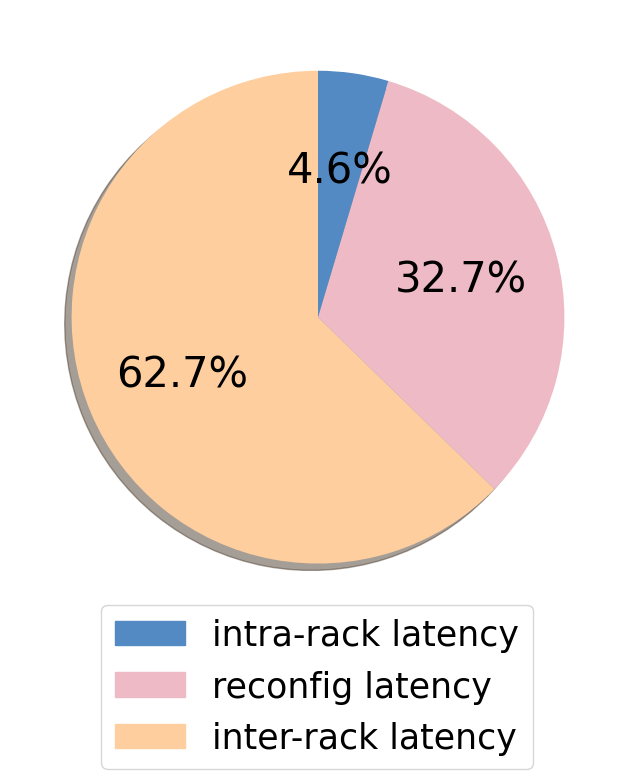

In [116]:
t1 = 0
t2 = 0
t3 = 0
t11 = 0
t22 = 0
t33 = 0
for j in [0,1,2,3]:
    diction[3][j].sort()
    t1 += diction[3][j][0] / diction[3][j][2]
    t2 += (diction[3][j][1] - diction[3][j][0]) / diction[3][j][2]
    t3 += (diction[3][j][2] - diction[3][j][1]) / diction[3][j][2]
    print(diction[3][j][0],diction[3][j][1],diction[3][j][2])
print(t1,t2,t3)
t1_ratio = t1/3
t2_ratio = t2/3
t3_ratio = t3/3
t1_ratio = t1/3
t2_ratio = t2/3
t3_ratio = t3/3
sizes = [t3_ratio, t2_ratio,t1_ratio]
crossrack_color, reconfig_color, inrack_color = '#ffce9f','#edbac5','#538ac3'
plt.figure(figsize=(8, 8))

wedges, _, autotexts = plt.pie(
    sizes,
    colors=[crossrack_color, reconfig_color, inrack_color],
    autopct='%1.1f%%',
    shadow=True,
    startangle=90,
    textprops={'fontsize': 30}
)

handles = [
    mpatches.Patch(color=inrack_color, label='#intra-rack latency'),
    mpatches.Patch(color=reconfig_color, label='#reconfig latency'),
    mpatches.Patch(color=crossrack_color, label='#inter-rack latency')
]

plt.legend(
    handles,
    ['intra-rack latency', 'reconfig latency', 'inter-rack latency'],
    loc="center left",
    bbox_to_anchor=(0.12, -0.1),
    fontsize=25,
    frameon=True
)
bbox = Bbox.from_bounds(1.43, -0.8, 5.35, 8)

plt.savefig('fig/FIG_12b.pdf', bbox_inches=bbox)
plt.show()


